# Example: Single Asset Geometric Brownian Motion (GBM) Models
In this example, we estimate the parameters of a geometric Brownian motion (GBM) model for a single asset from historical price data, check the assumptions behind the estimates, and then use the fitted model to simulate future price paths and compare them with what actually happened.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Estimate GBM parameters from historical prices:** Estimate the mean growth rate from a regression of log price on time, estimate the volatility from the growth-rate standard deviation scaled by the square root of the time step, and recover the arithmetic drift from the half-variance correction.
> * **Check the estimation assumptions honestly:** Run Anderson-Darling normality tests on the regression residuals and on the growth rates, understand why each rejects and what that does and does not say about GBM, and compute descriptive confidence intervals for the regression parameters.
> * **Simulate GBM and compare with market data:** Generate sample price paths from the fitted model, draw the central lognormal quantile bands together with the expected-price curve, and compare them with the observed price trajectory of a randomly selected firm over an in-sample window.

This is going to be interesting. Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period. 

Let's load the `original_dataset::DataFrame` by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and remove firms that do not have the maximum number of trading days. The cleaned dataset $\mathcal{D}$ will be stored in the `dataset` variable.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];

Not all tickers in our dataset have the maximum number of trading days for various reasons, such as acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has the maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow;

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # check if ticker has maximum trading days
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Finally, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable:

In [5]:
list_of_tickers = keys(dataset) |> collect |> sort; # list of firm "ticker" symbols in alphabetical order

### Constants
Finally, let's set some constants we'll use later in this notebook. The comments describe the constants, their units, and permissible values:

In [6]:
Δt = (1.0/252.0); # time step
T = 64; # length of simulation -> 1 trading quarter
all_range = range(1,stop=maximum_number_trading_days,step=1) |> collect;

___

## Task 1: Estimate the mean growth rate $\bar g$ from data
In this task, we estimate the mean growth rate $\bar g = \mu-\sigma^{2}/2$ from historical price data by regressing the log price on time. From the lecture, taking the logarithm of the GBM solution on the grid $t_{j} = j\Delta{t}$ gives $\ln(S_{t_{j}}) = \ln(S_{0}) + \bar g\,t_{j} + \sigma{W(t_{j})}$: the expected log price is a line with slope $\bar g$, and the Wiener term is the error. Given the log prices $\ln(S_{t_{0}}),\ldots,\ln(S_{t_{N}})$, we can construct an __overdetermined__ system of equations:
$$
\begin{align*}
\hat{\mathbf{X}}\mathbf{\theta} + \epsilon &= \mathbf{y}\\
\end{align*}
$$
where $\mathbf{\theta}$ is the parameter vector we want to estimate (the intercept $\ln(S_{0})$ and the slope $\bar g$), $\epsilon$ is the error vector, $\hat{\mathbf{X}}$ is the $(N+1)\times{2}$ (augmented) design matrix, and $\mathbf{y}$ is the $(N+1)\times{1}$ observation vector. Two things to keep in mind. First, the regression slope estimates the mean growth rate $\bar g$, not the arithmetic SDE drift $\mu$; after estimating the volatility in Task 2, we recover the drift from $\hat{\mu}=\widehat{\bar g}+\hat{\sigma}^{2}/2$. Second, under GBM the error $\sigma{W(t_{j})}$ is a Brownian path, correlated across dates with variance growing in time, so ordinary least squares gives a usable slope but its textbook standard errors do not apply; we will see this when we test the residuals below. The design matrix $\hat{\mathbf{X}}$ holds a column of ones and the grid times:
$$
\begin{align*}
\hat{\mathbf{X}} &= \begin{bmatrix}
1 & t_{0} \\
1 & t_{1} \\
\vdots & \vdots \\
1 & t_{N}
\end{bmatrix}\\
\end{align*}
$$
while the observation vector $\mathbf{y}$ holds the log prices:
$$
\begin{align*}
\mathbf{y} &= \begin{bmatrix}
\ln(S_{t_{0}}) \\
\ln(S_{t_{1}}) \\
\vdots \\
\ln(S_{t_{N}})
\end{bmatrix}\\
\end{align*}
$$
The parameter estimate $\hat{\mathbf{\theta}}$ has an analytical solution given by the normal equations:
$$
\boxed{
\begin{align*}
\hat{\mathbf{\theta}} &= (\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}})^{-1}\hat{\mathbf{X}}^{\top}\mathbf{y}\quad\blacksquare\\
\end{align*}}
$$
Let's solve the normal equations for every firm in `list_of_tickers` and store the intercept and slope in the `θ̂_dictionary::Dict{String,NamedTuple}` variable, keyed by ticker:

In [7]:
θ̂_dictionary = let

    # initialize -
    data = Dict{String, NamedTuple}();

    for ticker ∈ eachindex(list_of_tickers)
        firm_ticker = list_of_tickers[ticker];
        firm_data = dataset[firm_ticker];
        T_all = all_range*Δt .- Δt;

        A = [ones(maximum_number_trading_days) T_all];
        Y = log.(firm_data[!,:volume_weighted_average_price]);

        # Solve the normal equations
        θ = inv(transpose(A)*A)*transpose(A)*Y;

        # store the results in a named tuple -
        data[firm_ticker] = (b = θ[1], m = θ[2]);
    end
    data; # return
end

Dict{String, NamedTuple} with 424 entries:
  "EMR"  => (b = 3.92437, m = 0.0644198)
  "CTAS" => (b = 2.69144, m = 0.235649)
  "HSIC" => (b = 3.95725, m = 0.0386116)
  "KIM"  => (b = 3.12273, m = -0.0208058)
  "PLD"  => (b = 3.60571, m = 0.132629)
  "IEX"  => (b = 4.2588, m = 0.123906)
  "BAC"  => (b = 2.75484, m = 0.0930762)
  "CBOE" => (b = 4.0031, m = 0.107147)
  "EXR"  => (b = 4.0407, m = 0.109955)
  "NCLH" => (b = 4.107, m = -0.119297)
  "CVS"  => (b = 4.45628, m = -0.0196272)
  "DRI"  => (b = 3.97448, m = 0.111374)
  "DTE"  => (b = 4.42641, m = 0.0416772)
  "ZION" => (b = 3.42861, m = 0.0486871)
  "AVY"  => (b = 3.90957, m = 0.148483)
  "EW"   => (b = 2.98773, m = 0.171359)
  "EA"   => (b = 3.95994, m = 0.111369)
  "NWSA" => (b = 2.51942, m = 0.0508625)
  "CAG"  => (b = 3.6385, m = -0.0186004)
  "GILD" => (b = 4.47077, m = -0.0246717)
  "FCX"  => (b = 2.4883, m = 0.100435)
  "GPC"  => (b = 4.37165, m = 0.0563871)
  "UNP"  => (b = 4.54326, m = 0.0928863)
  "CDW"  => (b = 3.36536, m

### Check: Are the residuals normally distributed?
An ordinary regression assumes independent, identically distributed normal errors. Under GBM the error is $\sigma{W(t_{j})}$, a Brownian path, so we do not expect that assumption to hold, and it is worth seeing what the residuals actually look like. Let's compute the residuals `ϵ` for a randomly chosen firm, fit a normal distribution `ϵₙ` to them by maximum likelihood, and plot the two densities:

In [8]:
 ϵ, ϵₙ, rand_firm_ticker, A, Y = let
    rand_firm_ticker = rand(list_of_tickers)
    firm_data = dataset[rand_firm_ticker]
    T_all = all_range*Δt .- Δt;
    A = [ones(maximum_number_trading_days) T_all];
    Y = log.(firm_data[!,:volume_weighted_average_price]);
    
    θ = [
        θ̂_dictionary[rand_firm_ticker].b, # intercept
        θ̂_dictionary[rand_firm_ticker].m # slope
    ];

    ϵ = Y .- A*θ
    ϵₙ = fit_mle(Normal,ϵ);

    (ϵ, ϵₙ, rand_firm_ticker, A, Y); # return
end;

The plot compares the fitted normal density with the actual residual density. How well does the normal shape hold up? Let's look before we test.

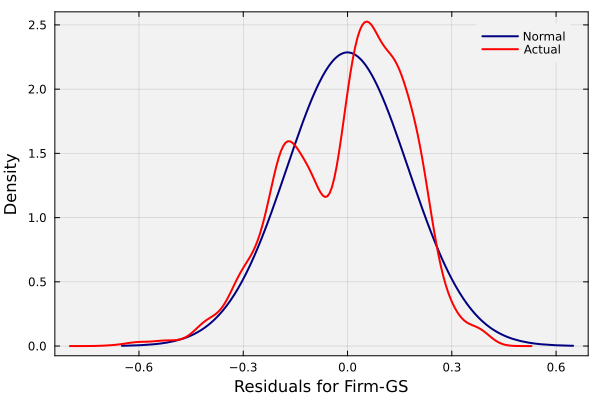

In [9]:
let 
    
    plot(ϵₙ, label="Normal", c=:navyblue,lw=2)
    density!(ϵ, normalize=true, xlabel="Residuals for Firm-$(rand_firm_ticker)", 
        ylabel="Density", label="Actual", c=:red,lw=2)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);

end

#### Anderson-Darling Test
Let's examine the AD test results for the residuals of the ticker specified in the `rand_firm_ticker::String` variable. What is an AD test?

> __Anderson-Darling test:__ The Anderson-Darling (AD) test is a statistical test of whether a given sample of data is drawn from a specified probability distribution. It is a type of goodness-of-fit test that compares the empirical cumulative distribution function of the sample data to the cumulative distribution function of the specified distribution. The AD test is particularly sensitive to differences in the tails of the distributions, making it useful for detecting deviations from the assumed distribution in those regions.

The test is stated as a null hypothesis and an alternative:

> __Null hypothesis:__ The Anderson-Darling test examines the null hypothesis that the data in vector $x$ come from the distribution $d$ against the alternative hypothesis that the sample is not drawn from $d$. This test reports a p-value, the probability that, assuming the null hypothesis is true (your data really are i.i.d. from $d$), the AD test statistic would be at least as extreme as the one computed from your data.

Notice the i.i.d. in that sentence; we will come back to it. One more caveat: we fit the normal to the same data we then test, which the standard p-value does not account for, so the test is slightly too eager to reject. That will not matter here, because the statistics turn out to be enormous.

> __TLDR:__ A small p-value or large $A^{2}$ statistic indicates that the null hypothesis is unlikely to be true, i.e., the data is unlikely to be drawn from the specified distribution $d$.

Let's perform a one-sample [Anderson-Darling test](https://en.wikipedia.org/wiki/Anderson–Darling_test), exported by the [HypothesisTests.jl package](https://juliastats.org/HypothesisTests.jl/stable/), of the `H0: null hypothesis` that the actual residual `ϵ` is drawn from the distribution `ϵₙ` against the `H1: alternative hypothesis` that the sample is not drawn from distribution `ϵₙ`:

In [10]:
AD_test_result = OneSampleADTest(ϵ,ϵₙ)

One sample Anderson-Darling test
--------------------------------
Population details:
    parameter of interest:   not implemented yet
    value under h_0:         NaN
    point estimate:          NaN

Test summary:
    outcome with 95% confidence: reject h_0
    one-sided p-value:           <1e-06

Details:
    number of observations:   2767
    sample mean:              8.936352441073902e-16
    sample SD:                0.17452978918111295
    A² statistic:             22.715144146424826


The test rejects decisively (a p-value below $10^{-6}$ and a large $A^{2}$ statistic). Before we blame the model, remember what the test assumes: independent, identically distributed draws from one normal distribution. Under GBM the regression errors are a Brownian path, so neighboring residuals are strongly correlated and their variance grows along the sample; pooled together they are a mixture of normals with different scales, which is not a single normal, and the AD test is not calibrated for dependent data in any case. So this rejection tells us that the ordinary regression assumptions fail here (which GBM itself predicts), not that GBM is wrong. The GBM-consistent normality check is on the __one-step growth rates__, which the model says are i.i.d. normal; we run that test in Task 2, and it fails for a different and more interesting reason.

Meanwhile, the slope of the fitted line is still a sensible estimate of $\bar g$. Let's see how well the fitted trend tracks the price.

### Check: How well does the deterministic trend describe the VWAP trajectory?
Before we estimate the volatility parameter $\sigma$, let's examine how well the volume-weighted average price (VWAP) is replicated by the fitted log-linear trend, and how uncertainty in the fitted line shows up.

> __Sampling:__ We resample the residuals from the fitted normal `ϵₙ` as if they were i.i.d., refit the parameter vector $\theta$ on each resampled dataset, and compute the corresponding fitted price trajectory. This is a descriptive device for the spread of the fitted trend line, not the GBM prediction band (that comes in Task 3, from the model itself). We store the fitted log-price trajectories in the `error_simulation_array::Array{Float64,2}` variable, one column per resample.

What do we observe?

In [11]:
error_simulation_array = let
    N = 1000;
    
    error_simulation_array = Array{Float64,2}(undef,maximum_number_trading_days,N);
    for i ∈ 1:N
        error = rand(ϵₙ,maximum_number_trading_days)
        θᵢ = inv(transpose(A)*A)*transpose(A)*Y + inv(transpose(A)*A)*transpose(A)*error
        Ŷᵢ = A*θᵢ
        for k ∈ 1:maximum_number_trading_days
            error_simulation_array[k,i] =  Ŷᵢ[k]
        end
    end

    error_simulation_array;
end

2767×1000 Matrix{Float64}:
 5.02733  5.01796  5.02614  5.00956  …  5.02308  5.01846  5.02556  5.01997
 5.02769  5.01832  5.02649  5.00993     5.02344  5.01883  5.02592  5.02033
 5.02804  5.01868  5.02685  5.0103      5.0238   5.01919  5.02628  5.02069
 5.0284   5.01905  5.02721  5.01067     5.02416  5.01955  5.02664  5.02106
 5.02876  5.01941  5.02756  5.01104     5.02453  5.01991  5.027    5.02142
 5.02912  5.01977  5.02792  5.01141  …  5.02489  5.02027  5.02736  5.02178
 5.02948  5.02013  5.02827  5.01178     5.02525  5.02063  5.02772  5.02214
 5.02983  5.02049  5.02863  5.01215     5.02561  5.02099  5.02808  5.0225
 5.03019  5.02085  5.02898  5.01252     5.02598  5.02135  5.02844  5.02286
 5.03055  5.02122  5.02934  5.01289     5.02634  5.02171  5.0288   5.02322
 5.03091  5.02158  5.0297   5.01326  …  5.0267   5.02207  5.02916  5.02358
 5.03127  5.02194  5.03005  5.01363     5.02706  5.02243  5.02952  5.02394
 5.03163  5.0223   5.03041  5.014       5.02742  5.0228   5.02988  5.02431

`Unhide` the code block below to see how we compute and plot the expected VWAP and its uncertainty. We plot the pointwise $0.05\%$ and $99.95\%$ quantiles of the resampled fitted prices in gray (a 99.9% band for the trend line) around the fitted deterministic VWAP shown in red.

> __Summary:__ The deterministic price trend parameterized by the mean growth rate $\bar g$ tracks the central trend of the VWAP. However, this trend alone does not describe the random fluctuations observed around the price.

To account for the randomness, we must include the model's random component, which requires estimating the volatility parameter $\sigma$, which sets the size of the noise term.

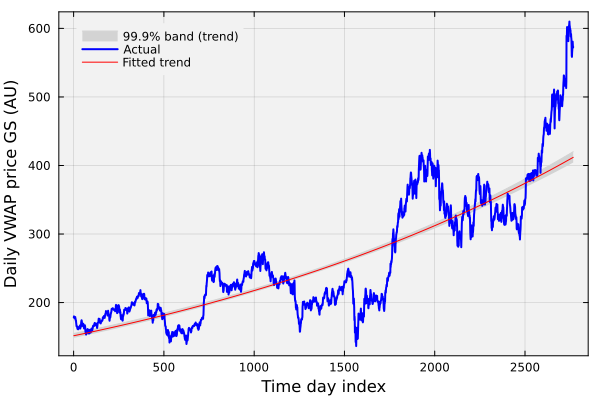

In [12]:
let
    
    θ = [
        θ̂_dictionary[rand_firm_ticker].b, # intercept
        θ̂_dictionary[rand_firm_ticker].m # slope
    ];
    
    Ŷ = A*θ;
    P = exp.(error_simulation_array); # fitted price trajectories, one per column
    lower_value = [quantile(P[k,:], 0.0005) for k ∈ 1:size(P,1)]; # pointwise 0.05% quantile
    upper_value = [quantile(P[k,:], 0.9995) for k ∈ 1:size(P,1)]; # pointwise 99.95% quantile
    plot(upper_value, fillrange=lower_value, label="99.9% band (trend)", c=:lightgray)
    plot!(exp.(Y),c=:blue,lw=2, label="Actual")
    plot!(exp.(Ŷ),c=:red,lw=1, label="Fitted trend")
    xlabel!("Time day index", fontsize=18);
    ylabel!("Daily VWAP price $(rand_firm_ticker) (AU)", fontsize=18)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

### Curious: Why is the uncertainty region curved?
The uncertainty region around the mean deterministic price prediction is curved. This occurs because the noise model will [perturb both the slope and the intercept of the regression line](https://stats.stackexchange.com/questions/85560/shape-of-confidence-interval-for-predicted-values-in-linear-regression). 

`Unhide` the code block below to see how we plotted individual estimated best-fit lines for the parameter vector $\theta$.

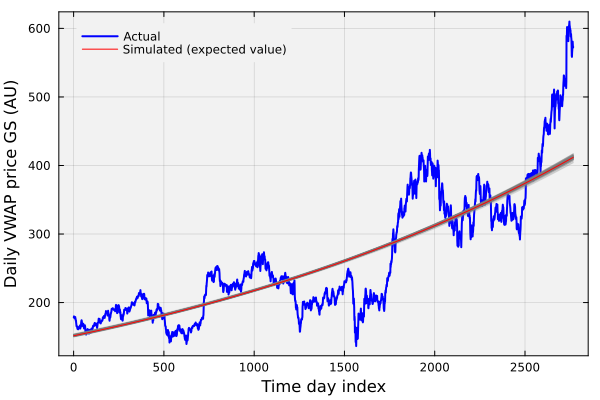

In [13]:
let

    N = 1000;
    θ = [
        θ̂_dictionary[rand_firm_ticker].b, # intercept
        θ̂_dictionary[rand_firm_ticker].m # slope
    ];


    Yₘ = A*θ;
    skip = 10;
    plot(exp.(Y),c=:blue,lw=2, label="Actual")
    mean_value = mean(exp.(error_simulation_array),dims=2);
    for i ∈ 1:skip:N
        Ŷ = error_simulation_array[:,i];
        plot!(exp.(Ŷ), c=:gray50, label="", alpha=0.25)
    end
    current()
    plot!(exp.(Yₘ),c=:red,lw=1, label="Simulated (expected value)")
    xlabel!("Time day index", fontsize=18);
    ylabel!("Daily VWAP price $(rand_firm_ticker) (AU)", fontsize=18)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

### Compute the uncertainty in the $\theta$ estimate
Let's compute confidence intervals for the estimated model parameters $\hat{\mathbf{\theta}}$. To do this, we need the standard errors of the parameter estimates $\mathrm{SE}(\hat{\mathbf{\theta}})$, which requires an estimate of the variance of the error terms $\hat{\sigma}_{\epsilon}^{2}$. These are the textbook formulas for i.i.d. errors. We just saw that the errors here are not i.i.d., so treat the intervals below as __descriptive__: they say how much the fitted line would move under an i.i.d. error model, not how uncertain $\bar g$ is under GBM (which is considerably more; see the optional advanced material).

Let's start with the error variance.

> __Theory:__ Since the __true__ error variance is unknown, we estimate it from the residuals $\mathbf{r} = \mathbf{y} - \hat{\mathbf{X}}\hat{\mathbf{\theta}}$ as:
> $$
\begin{align*}
\hat{\sigma}_{\epsilon}^{2} &= \frac{\lVert~\mathbf{r}~\rVert^{2}_{2}}{n-p} = \frac{1}{n-p}\sum_{i=1}^{n}r_i^2
\end{align*}
> $$
> where $n$ is the number of observations, $p$ is the number of parameters, $\lVert\star\rVert_{2}^{2}$ denotes the 2-norm squared, and $r_i = y_i - \hat{\mathbf{x}}_i^{\top}\hat{\mathbf{\theta}}$ is the $i$-th residual, i.e., the difference between the observed and predicted value for observation $i$.

We implement this computation in the code block below and save the result in the `training_variance::Float64` variable.

In [14]:
training_variance = let

    θ̂ = [
        θ̂_dictionary[rand_firm_ticker].b, # intercept
        θ̂_dictionary[rand_firm_ticker].m # slope
    ];


    # initialize -
    p = length(θ̂); # number of parameters
    n = size(A,1); # number of training observations

    # compute the residual -
    r = Y .- A*θ̂;

    # variance -
    my_variance = (1/(n-p))*norm(r)^2

    # let's compute the variance of the residuals (Julia)
    built_in_variance = var(r, corrected=true); # variance - Julia
    @show built_in_variance, my_variance; # show

    my_variance; # return
end;

(built_in_variance, my_variance) = (0.030460647311603733, 0.030471663820577113)


Next, let's compute the standard error. The standard error of the parameter estimates $\hat{\mathbf{\theta}}$ quantifies the uncertainty in the estimated parameters due to the variability in the data. Let's compute the standard error for each parameter $\hat{\theta}$ where we save the standard errors in the `SE::Vector{Float64}` variable, where element $j$ corresponds to the standard error of a parameter estimate $\text{SE}(\hat{\theta}_j)$.

In [15]:
SE = let


    θ̂ = [
        θ̂_dictionary[rand_firm_ticker].b, # intercept
        θ̂_dictionary[rand_firm_ticker].m # slope
    ];
    
    # initialize -
    p = length(θ̂); # number of parameters
    n = size(A,1); # number of training samples

    # compute the standard error -
    SE = sqrt.(diag(inv(transpose(A)*A))*training_variance);

    SE; # return
end;

Now that we have the standard error for each of the model parameters, we can compute confidence intervals for the parameter estimates $\hat{\mathbf{\theta}}$.
> __Confidence Intervals:__ A $(1-\alpha)\times{100}\%$ confidence interval for each parameter $\hat{\theta}_j$ is given by:
> $$
\begin{align*}
\hat{\theta}_j \pm t_{1-\alpha/2,\nu}\; \hat{\sigma}_{\epsilon}\; \sqrt{\bigl[(\hat{\mathbf X}^\top\hat{\mathbf X})^{-1}\bigr]_{jj}}
\end{align*}
$$
> where $t_{1-\alpha/2,\nu}$ is the $(1-\alpha/2)$-quantile of a Student $t$ distribution with $\nu = n-p$ degrees of freedom. With thousands of observations, $\nu$ is large and the $t$ quantile is essentially the normal one: for a 95% interval, $\alpha = 0.05$ and $t_{1-\alpha/2,\nu} \approx 1.96$; for a 99.9% interval, $\alpha = 0.001$ and $t_{1-\alpha/2,\nu} \approx 3.291$.

Let's build a table that shows the parameter ranges for a 95.0% confidence interval using [the `PrettyTables.jl` package](https://github.com/ronisbr/PrettyTables.jl). (You can adjust this to show another confidence interval if you like).

In [16]:
let

    θ̂ = [
        θ̂_dictionary[rand_firm_ticker].b, # intercept
        θ̂_dictionary[rand_firm_ticker].m # slope
    ];

    # initialize -
    t = 1.96; # for a 95% confidence interval
    df = DataFrame(); # hold the data (rows) for the table

    # build features of the table -
    feature_labels = Array{String,1}();
    push!(feature_labels, "intercept"); # add the intercept label
    push!(feature_labels, "slope"); # add the slope label

    for i ∈ eachindex(θ̂)

        center = θ̂[i];
        lower_bound = θ̂[i] - t*SE[i];
        upper_bound = θ̂[i] + t*SE[i];

        row_df = (
            i = i,
            feature = feature_labels[i],
            p = round(center, digits=4),
            l = round(lower_bound, digits=4),
            u = round(upper_bound, digits=4),
            cz = (lower_bound <= 0.0 <= upper_bound ? "yes" : "no")
        ) # data for the row

        push!(df, row_df) # add the row to the dataframe
    end

    # show the table -
    pretty_table(df, 
        table_format = TextTableFormat(borders = text_table_borders__simple)) # new table API. Hmmm
end

======== =========== ========= ========= ========= =========
      i     feature         p         l         u       cz 
  Int64      String   Float64   Float64   Float64   String 
======== =========== ========= ========= ========= =========
      1   intercept    5.0212    5.0082    5.0342       no
      2       slope    0.0911     0.089    0.0931       no
======== =========== ========= ========= ========= =========


___

## Task 2: Estimate the volatility parameter $\sigma$ from data
In this task, we will estimate the volatility parameter $\sigma$ from historical data for all firms in the `dataset` $\mathcal{D}$. First, we compute the log growth rates for the firms in the `list_of_tickers` $\mathcal{L}$ using the `log_growth_matrix(...)` function.

[The `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) takes `dataset` $\mathcal{D}$ and a list of firms $\mathcal{L}$ and computes growth-rate values for each firm as a function of time. The data is returned as a $\left(\dim\mathcal{D}_{i} - 1\right)\times\dim\mathcal{L}$ array (time on the rows, firms on the columns).

We store the data in the `log_growth_array::Array{Float64,2}` variable:

In [17]:
log_growth_array = log_growth_matrix(dataset, list_of_tickers);

### Estimate the volatility parameter $\sigma$
From the lecture, the one-step growth rate under GBM is $g_{j} = \bar g + (\sigma/\sqrt{\Delta{t}})Z_{j}$, so the sample standard deviation $\sigma_{g}$ of a growth-rate series estimates $\sigma/\sqrt{\Delta{t}}$, and the volatility estimate is:
$$
\hat{\sigma} = \sigma_{g}\sqrt{\Delta{t}}
$$
For daily data, $\Delta{t} = 1/252$ years, so this divides the daily growth-rate standard deviation by $\sqrt{252}$ (equivalently, it multiplies the standard deviation of the daily log returns $g_{j}\Delta{t}$ by $\sqrt{252}$). We compute $\sigma_{g}$ with [the `std(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.std) exported by the `Statistics.jl` package (the corrected sample standard deviation, denominator $N-1$, as in the lecture).

We save the annualized volatility estimate for each firm in the `σ̂_dictionary::Dict{String, Float64}` variable, where the key is the ticker symbol and the value is $\hat{\sigma}$ (units: inverse years to the one-half power):

In [18]:
σ̂_dictionary = let

    # initialize -
    σ̂_dictionary = Dict{String,Float64}();

    # process each firm in the list_of_tickers -
    for i ∈ eachindex(list_of_tickers)
        
        firm_ticker = list_of_tickers[i];
        samples = log_growth_array[:,i]; # one-step growth rates g_j (units: 1/years)
        σ_g = std(samples); # sample standard deviation of the growth rates, estimates σ/sqrt(Δt)
        σ̂_dictionary[firm_ticker] = σ_g*sqrt(Δt); # GBM volatility estimate σ̂ = σ_g sqrt(Δt)
    end
    σ̂_dictionary; # return
end

Dict{String, Float64} with 424 entries:
  "EMR"  => 0.240266
  "CTAS" => 0.224216
  "HSIC" => 0.236095
  "KIM"  => 0.292401
  "PLD"  => 0.22024
  "IEX"  => 0.196322
  "BAC"  => 0.268701
  "CBOE" => 0.207386
  "EXR"  => 0.226115
  "NCLH" => 0.52651
  "CVS"  => 0.243167
  "DRI"  => 0.31498
  "DTE"  => 0.196962
  "ZION" => 0.34659
  "AVY"  => 0.227346
  "EW"   => 0.294303
  "EA"   => 0.253129
  "NWSA" => 0.26372
  "CAG"  => 0.24538
  "GILD" => 0.236529
  "FCX"  => 0.481171
  "GPC"  => 0.234831
  "UNP"  => 0.305667
  "CDW"  => 0.247707
  "SBUX" => 0.240401
  ⋮      => ⋮

### Check: Are the growth rates normally distributed?
GBM says the one-step growth rates are i.i.d. normal, so this, rather than the regression residuals, is the right place to test the Gaussian assumption. Let's run the same Anderson-Darling test on the growth rates of the firm in `rand_firm_ticker`, against a normal distribution fitted to them by maximum likelihood:

In [19]:
let
    i = findfirst(x-> x == rand_firm_ticker, list_of_tickers); # column of the random firm
    g = log_growth_array[:,i]; # one-step growth rates
    gₙ = fit_mle(Normal, g); # fitted normal
    println("Excess kurtosis of the growth rates for $(rand_firm_ticker): $(round(kurtosis(g), digits = 2)) (zero for a normal distribution)")
    OneSampleADTest(g, gₙ) # H0: g is drawn from gₙ
end

Excess kurtosis of the growth rates for GS: 5.96 (zero for a normal distribution)


One sample Anderson-Darling test
--------------------------------
Population details:
    parameter of interest:   not implemented yet
    value under h_0:         NaN
    point estimate:          NaN

Test summary:
    outcome with 95% confidence: reject h_0
    one-sided p-value:           <1e-06

Details:
    number of observations:   2766
    sample mean:              0.10643921521104635
    sample SD:                3.8983471955810103
    A² statistic:             22.276219139998645


This test also rejects, and now the rejection is consistent with what we found in L3a: empirical growth rates are __heavy tailed__, with more extreme days than a normal distribution allows (the excess kurtosis printed above is well above zero; a normal distribution has none). A rejection by itself does not say which feature of the data is non-normal, but the L3a diagnostics do, and heavy tails are a genuine limitation of GBM that the lecture predicted from the model's structure. So the two tests say different things. The residual test failed on a sample that violates the regression's i.i.d. assumption, as GBM says it must; the growth-rate test fails because the Gaussian assumption is wrong in the tails of real data. The volatility estimate $\hat{\sigma}$ still summarizes the typical size of daily moves, but we should not expect the model to reproduce the extremes.

### Check: Do the two estimators of $\bar g$ agree?
The lecture gave two estimators of the mean growth rate: Method 1, the sample mean $g^{\prime}$ of the growth rates, and Method 2, the regression slope, which is what we stored in `θ̂_dictionary`. Both estimate $\bar g$, but they are different statistics and need not agree closely on one sample. Let's compare them for the random firm:

In [20]:
let
    i = findfirst(x-> x == rand_firm_ticker, list_of_tickers);
    g_prime = mean(log_growth_array[:,i]);          # Method 1: sample mean of the growth rates
    slope = θ̂_dictionary[rand_firm_ticker].m;        # Method 2: regression slope
    println("Firm-$(rand_firm_ticker): Method 1 (sample mean) ḡ = $(round(g_prime, digits = 4)); Method 2 (regression slope) ḡ = $(round(slope, digits = 4)); difference = $(round(g_prime - slope, digits = 4)) per year")
end

Firm-GS: Method 1 (sample mean) ḡ = 0.1064; Method 2 (regression slope) ḡ = 0.0911; difference = 0.0154 per year


The two estimates differ by a few hundredths per year. That is well inside the honest uncertainty of either estimator: with eleven years of daily data and a volatility near 0.3, the standard error of the sample mean is about 0.09 per year, and the regression slope is slightly worse (the optional drift-uncertainty notebook works this out). Neither number is precise; the disagreement between them is a reminder of that, not a bug.

### Save the data
Finally, let's save the mean growth and volatility estimates for later use in the `parameters_df::DataFrame` variable and write it to `SAGBM-Parameters-Fall-2025.csv` in the `data` directory. Two notes on the columns. For compatibility with existing examples, the CSV retains the legacy column name `drift`, but that column stores the mean growth rate estimate $\widehat{\bar g}$; any GBM simulation must convert it using $\hat{\mu}=\widehat{\bar g}+\hat{\sigma}^2/2$. The `lower_bound_drift` and `upper_bound_drift` columns are the descriptive 95% regression interval for $\widehat{\bar g}$ (not for $\mu$), computed firm by firm from each firm's own residual variance; the design matrix `A` is the same for every firm because they share the same trading days:

In [21]:
parameters_df = let
    
    # initialize -
    parameters_df = DataFrame();
    t = 1.96; # for a 95% confidence interval
    p = 2; # number of regression parameters
    n = size(A,1); # number of observations (same for every firm)
    G = inv(transpose(A)*A); # shared (XᵀX)⁻¹

    # process each firm in the list_of_tickers -
    for i ∈ eachindex(list_of_tickers)
        
        firm_ticker = list_of_tickers[i];
        θ̂ᵢ = [θ̂_dictionary[firm_ticker].b, θ̂_dictionary[firm_ticker].m]; # this firm's fit
        ĝ = θ̂ᵢ[2]; # mean growth rate estimate (slope)
        σ̂ = σ̂_dictionary[firm_ticker];

        # this firm's residual variance and slope standard error -
        Yᵢ = log.(dataset[firm_ticker][!,:volume_weighted_average_price]);
        rᵢ = Yᵢ .- A*θ̂ᵢ;
        s²ᵢ = (1/(n-p))*norm(rᵢ)^2;
        SEᵢ = sqrt(G[2,2]*s²ᵢ);
        
        data_tuple = ( 
            ticker = firm_ticker,
            drift =  ĝ, # legacy column name; stores the mean growth rate estimate
            t = t,
            lower_bound_drift = ĝ - t*SEᵢ,
            upper_bound_drift = ĝ + t*SEᵢ,
            volatility = σ̂
        );
        
        push!(parameters_df, data_tuple)
    end

    # save the data to a CSV file -
    CSV.write(joinpath(_PATH_TO_DATA,"SAGBM-Parameters-Fall-2025.csv"), parameters_df);

    parameters_df; # return
end

Row,ticker,drift,t,lower_bound_drift,upper_bound_drift,volatility
,String,Float64,Float64,Float64,Float64,Float64
1,A,0.147468,1.96,0.145642,0.149294,0.231467
2,AAL,-0.141294,1.96,-0.144465,-0.138123,0.455075
3,AAP,-0.0481021,1.96,-0.0523949,-0.0438093,0.342624
4,AAPL,0.24271,1.96,0.240519,0.2449,0.234516
5,ABBV,0.116,1.96,0.114452,0.117547,0.242982
6,ABT,0.123083,1.96,0.121184,0.124982,0.199759
7,ACN,0.151012,1.96,0.149658,0.152367,0.214406
8,ADBE,0.224401,1.96,0.22129,0.227511,0.276323
9,ADI,0.146449,1.96,0.145339,0.147558,0.259376


___

## Task 3: Visualize the simulation of a random firm for a random period
Now that we have the GBM parameter estimates for each firm in `dataset` $\mathcal{D}$, we can run simulations to see how the single asset GBM performs. Let's begin by selecting a random firm from our list of firms $\mathcal{L}$, get its price data, and store this in the `random_firm_data` variable:

In [22]:
random_firm_ticker = rand(list_of_tickers)
random_firm_data = dataset[random_firm_ticker];
println("The (randomly) selected firm in this study: $(random_firm_ticker)")

The (randomly) selected firm in this study: SPG


Next, randomly choose a contiguous time window of `T` days and analyze the model's performance during this period. To begin, randomly generate the `start_index` variable, i.e., the trading day index to start the simulation. The `stop_index` will then be determined by adding the number of trading days `T` to the `start_index`:

In [23]:
start_index = rand(1:(maximum_number_trading_days - T))
stop_index = start_index + T
println("Visualize Firm-$(random_firm_ticker) between trading days ($(start_index) -> $(stop_index))")

Visualize Firm-SPG between trading days (994 -> 1058)


Next, get the parameter values from the respective dictionaries for the randomly selected firm:

In [24]:
ĝ = θ̂_dictionary[random_firm_ticker].m; # use the expected value of the slope
σ̂ = σ̂_dictionary[random_firm_ticker];
println("Firm-$(random_firm_ticker) has (ĝ,σ̂) = ($(ĝ),$(σ̂))")

Firm-SPG has (ĝ,σ̂) = (-0.04738931255788213,0.3139231644038974)


### Generate sample price trajectories for a GBM model
Create an instance of [the `MyGeometricBrownianMotionEquityModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyGeometricBrownianMotionEquityModel) using [the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.build-Tuple{Type{MyGeometricBrownianMotionEquityModel},%20NamedTuple}). 

The fitted slope $\widehat{\bar g}$ estimates the mean growth rate. Before calling `build(...)`, we convert it to the arithmetic GBM price-SDE drift $\hat{\mu}=\widehat{\bar g}+\hat{\sigma}^2/2$. The package model therefore receives the arithmetic drift and volatility.

We store the GBM model instance in the `model::MyGeometricBrownianMotionEquityModel` variable:

In [25]:
μ̂ = ĝ + 0.5*σ̂^2; # arithmetic GBM drift: E[g] = μ - σ²/2
model = build(MyGeometricBrownianMotionEquityModel, (
            μ = μ̂, σ = σ̂ )); # package API uses μ for the GBM price-SDE drift

Then, we solve the model between `T₁` and `T₂` starting with price `Sₒ` using [the `sample(…)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.sample-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}) for `number_of_paths::Int64` sample paths. 

In [26]:
Sₒ = random_firm_data[start_index,:volume_weighted_average_price];
T₁ = start_index*Δt
T₂ = stop_index*Δt

# generate sample paths using the GBM model
X = VLQuantitativeFinancePackage.sample(model, (Sₒ = Sₒ, T₁ = T₁, T₂ = T₂, Δt = Δt), 
    number_of_paths = 100);

In addition to the numerical samples, we have analytical expressions for both the expected value and the variance of the share price. We've implemented these calculations in [the `expectation(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.expectation-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}) and [the `variance(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.variance-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}). Let's call these functions to get analytical values for the expectation and variance of the VWAP:

In [27]:
expectation_array = expectation(model, (Sₒ = Sₒ, T₁ = T₁, T₂ = T₂, Δt = Δt));
variance_array = variance(model, (Sₒ = Sₒ, T₁ = T₁, T₂ = T₂, Δt = Δt));

`Unhide` the block below to see how we plot the expected value of the simulated share price versus the actual share price, along with the sampled trajectories. The shaded regions are the exact __lognormal quantile bands__ of the GBM price: at elapsed time $\tau$ from the start of the window, the price satisfies $S = S_{0}\exp[(\hat{\mu}-\hat{\sigma}^{2}/2)\tau + \hat{\sigma}\sqrt{\tau}\,Z]$, so its central 68%, 95%, and 99% intervals are $S_{0}\exp[(\hat{\mu}-\hat{\sigma}^{2}/2)\tau \pm z\,\hat{\sigma}\sqrt{\tau}]$ with $z = 1, 1.96, 2.576$. (Mean plus or minus $z$ standard deviations would be wrong here: the lognormal distribution is skewed, so those are not its quantiles, and the lower edge can even go negative.) The dashed line is the analytical expected price, which sits above the median because of the half-variance correction.

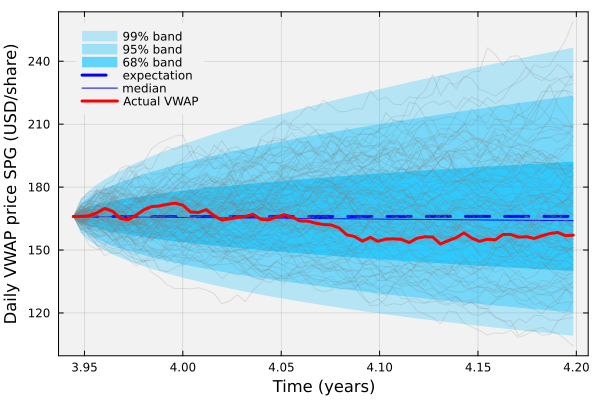

In [28]:
let
    
    # Initialize -
    time_axis = expectation_array[:,1]; # absolute time (years)
    τ = time_axis .- time_axis[1]; # elapsed time from the start of the window
    median_value = Sₒ*exp.((μ̂ - 0.5*σ̂^2)*τ); # lognormal median
    band(z) = (median_value.*exp.(-z*σ̂*sqrt.(τ)), median_value.*exp.(z*σ̂*sqrt.(τ))); # exact quantile band
    (L68,U68) = band(1.0); (L95,U95) = band(1.96); (L99,U99) = band(2.576);

    plot(time_axis, U99, fillrange=L99, c=:deepskyblue1, alpha=0.25, label="99% band", lw=0)
    plot!(time_axis, U95, fillrange=L95, c=:deepskyblue1, alpha=0.35, label="95% band", lw=0)
    plot!(time_axis, U68, fillrange=L68, c=:deepskyblue1, alpha=0.6, label="68% band", lw=0)
    plot!(time_axis, expectation_array[:,2], c=:blue, lw=3, ls=:dash, label="expectation")
    plot!(time_axis, median_value, c=:blue, lw=1, label="median")

    for i ∈ 2:size(X,2) # column 1 is time, columns 2:end are the sample paths
        plot!(X[:,1], X[:,i], c=:gray50, lw=1, alpha=0.2, label="") # sample paths
    end

    plot!(time_axis, random_firm_data[start_index:stop_index,:volume_weighted_average_price], c=:red, lw=3, label="Actual VWAP")
    xlabel!("Time (years)", fontsize=18)
    ylabel!("Daily VWAP price $(random_firm_ticker) (USD/share)", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topleft);
end

#### Check: Was this a successful GBM simulation?
Determining whether a model accurately represents data can be done in various ways, but we will use a simple, straightforward functional test on the __pointwise__ 99% lognormal band. 

> __Functional test__
> 
> * __Success__: If the observed price falls within the lower bound ($L_{j}$) and upper bound ($U_{j}$) of the pointwise 99% band for all times $t_j$ in the window, then the model is deemed a `success.`
> * __Failure__: However, if the actual price exceeds the given bounds __at any point__, the simulation is considered a `failure.`

Two caveats. The band is pointwise: with $T+1$ daily checks, even a correct model would produce at least one excursion far more often than 1% of the time, so a single failure is not by itself evidence against GBM. And this window is drawn from the same 2014-2024 data used to estimate the parameters, so this is an in-sample check; the out-of-sample version is in L5a. So, did we succeed or fail (for this ticker and time period)?

In [29]:
let
    z = 2.576; # 99% two-sided lognormal band
    time_axis = expectation_array[:,1];
    τ = time_axis .- time_axis[1];
    median_value = Sₒ*exp.((μ̂ - 0.5*σ̂^2)*τ);
    L = median_value.*exp.(-z*σ̂*sqrt.(τ));
    U = median_value.*exp.(z*σ̂*sqrt.(τ));
    actual = random_firm_data[start_index:stop_index,:volume_weighted_average_price]; # T+1 observations
    @assert length(actual) == length(L) "band and observation lengths differ"
       
    # check the bounds: if below L, or above U at any date then the simulation failed
    success_flag = true;
    for k ∈ eachindex(actual)
        if (actual[k] < L[k]) || (actual[k] > U[k])
            success_flag = false;
            break;
        end
    end
    
    println("The simulation of the VWAP of Firm-$(random_firm_ticker) between ($(start_index) -> $(stop_index)) was successful: $(success_flag)")
end

The simulation of the VWAP of Firm-SPG between (994 -> 1058) was successful: true


___

## Summary
In this example, we estimated GBM parameters from historical S&P500 data, tested the assumptions behind the estimates, and compared simulated price bands with the observed price trajectory of a randomly selected firm.

> __Key Takeaways:__
>
> * **Growth and drift are related but distinct:** Regression on log prices estimates the mean growth rate, the growth-rate standard deviation scaled by the square root of the time step estimates the volatility, and the arithmetic GBM drift is the mean growth rate plus half the variance.
>
> * **Two normality tests, two different lessons:** The regression residuals fail the Anderson-Darling test because the regression's independence assumption is wrong under GBM, so its standard errors are only descriptive; the growth rates fail because real markets have heavy tails, which is a genuine limitation of the model.
>
> * **GBM tracks the central trend and gives honest quantile bands:** The exact lognormal bands from the fitted model bracket the observed price much of the time, while extreme moves and volatility clustering fall outside what the model can represent.

Parameter estimation and validation must therefore be treated as one workflow: a calibrated GBM is useful only when its assumptions and out-of-sample limitations are made explicit.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance.  Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___